# H1-C ordering test — joint verdict across 3 motifs × 3 sizes

**Phase 2 headline deliverable** (HYPOTHESIS.md §H2-9 deliverable 4).

Tests the registered H1-C hypothesis: **μ_induction < μ_successor < μ_S-inhibition** for all three Pythia sizes (70m, 160m, 410m). Joint test under H_0 (exchangeable order in each size) gives p = (1/6)³ ≈ 0.00463; the locked gate is **p < 0.005** (`HYPOTHESIS.md §3 falsification criterion`).

Inputs: 40-cell × 3-size sweep parquets and per-prompt cache `.npz` files for each motif (induction, successor, S-inhibition), produced by the three `_run_phase2_*_sweep.py` scripts. Threshold values are pre-locked: induction prefix-match > 0.3 (brief §4); successor τ_lift = 0.13496 (§SU-tau); S-inhibition τ_strict = 0.0372 (§S-tau).

**Seven sub-deliverables (§H2-9):**
1. Joint H1-C permutation-test verdict (the gate).
2. Emergence-step μ table with bootstrap CIs across all 9 (size, motif) cells.
3. Per-pair descriptive p-values for the 9 sub-tests (uncorrected, §H2-5).
4. Side-by-side emergence-comparison curves (3 panels, one per size; three motif curves per panel).
5. Major differences between the three head types — depth, count saturation, cross-category breadth, identity stability.
6. Threshold-sensitivity check.
7. Verdict.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import (
    tiered_fit, evaluate_ordering, joint_h1c_test, RIGHT_CENSOR_STEP,
)
from src.analysis.phase2_bootstrap import (
    bootstrap_induction, bootstrap_successor, bootstrap_s_inhibition,
    summarize_bootstrap, THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m']
MOTIFS = ['induction', 'successor', 's_inhibition']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green'}
MOTIF_MARKER = {'induction': '^', 'successor': 's', 's_inhibition': 'o'}
MOTIF_LINESTYLE = {'induction': '--', 'successor': '-.', 's_inhibition': '-'}

INDUCTION_THRESHOLD = 0.3
TAU_LIFT = 0.13496
TAU_STRICT = 0.0372

## Sub-deliverable 2 — Emergence-step μ table with bootstrap CIs

For each (size, motif), fit logistic per §H2-3 tiered handling and compute B=1000 prompt-bootstrap 95% CI on μ per §H2-2.

In [2]:
df_ind = read_long(REPO / 'data' / 'exploration' / 'phase2_induction_sweep.parquet')
df_suc = read_long(REPO / 'data' / 'exploration' / 'phase2_successor_sweep.parquet')
df_si = read_long(REPO / 'data' / 'exploration' / 'phase2_s_inhibition_sweep.parquet')

def per_size_curve(df, size, threshold, comparator='gt'):
    sub = df[df['size'] == size].copy()
    if comparator == 'gt':
        passes = (sub['score'] > threshold).astype(int)
    else:
        passes = (sub['score'] >= threshold).astype(int)
    sub['passes'] = passes
    grouped = sub.groupby('step')['passes'].sum().sort_index()
    return grouped.index.values, grouped.values

rng = np.random.default_rng(0)
rows = []
for size in SIZES:
    for motif, df, threshold, comparator in [
        ('induction', df_ind, INDUCTION_THRESHOLD, 'gt'),
        ('successor', df_suc, TAU_LIFT, 'gte'),
        ('s_inhibition', df_si, TAU_STRICT, 'gte'),
    ]:
        steps, counts = per_size_curve(df, size, threshold, comparator)
        # Bootstrap on cached per-prompt arrays
        cache_dir = REPO / 'data' / 'exploration'
        if motif == 'induction':
            per_seq = {int(s): np.load(cache_dir / 'phase2_induction_per_seq' / f'{size}_step{s}.npz')['per_sequence_scores'] for s in steps}
            mus, mu_point = bootstrap_induction(per_seq, threshold, rng, B=1000)
        elif motif == 'successor':
            per_pp = {}
            for s in steps:
                npz = np.load(cache_dir / 'phase2_successor_per_prompt' / f'{size}_step{s}.npz')
                per_pp[int(s)] = {'real': npz['per_prompt_real'], 'null': npz['per_prompt_null'], 'cats': npz['prompt_categories']}
            mus, mu_point = bootstrap_successor(per_pp, threshold, rng, B=1000)
        else:
            per_pp = {}
            nm_layers = {}
            for s in steps:
                npz = np.load(cache_dir / 'phase2_s_inhibition_per_prompt' / f'{size}_step{s}.npz')
                per_pp[int(s)] = npz['per_prompt_delta']
                nm_layers[int(s)] = npz['nm_heads'][:, 0].tolist()
            a_grp = df_si[(df_si['size'] == size) & (df_si['step'] == steps[0])]
            n_layers = int(a_grp['layer'].max() + 1); n_heads = int(a_grp['head'].max() + 1)
            sender_layers = np.array([L for L in range(n_layers) for _ in range(n_heads)])
            mus, mu_point = bootstrap_s_inhibition(per_pp, threshold, nm_layers, sender_layers, rng, B=1000)
        bres = summarize_bootstrap(size, motif, threshold, mus, mu_point)
        # Per §H2-3, marginal regime uses bootstrap-median μ as point estimate.
        fr = tiered_fit(size, motif, steps, counts,
                        bootstrap_median_mu=bres.mu_bootstrap_median)
        rows.append(dict(
            size=size, motif=motif, regime=fr.regime, max_count=fr.max_count,
            mu_point=fr.mu, mu_boot_median=bres.mu_bootstrap_median,
            ci_low=bres.mu_ci_low, ci_high=bres.mu_ci_high,
        ))
mu_df = pd.DataFrame(rows)
print(mu_df.to_string(index=False, float_format=lambda v: f'{v:.0f}' if v == int(v) else f'{v:.2f}'))

size        motif   regime  max_count   mu_point  mu_boot_median   ci_low    ci_high
 70m    induction  emerged          6     640.53          640.53   639.81     640.53
 70m    successor marginal          2    8670.46         8670.46  4400.02 2000000.00
 70m s_inhibition censored          1     143000          143000   143000     143000
160m    induction  emerged         17    6086.87         6138.34  4479.97    9052.75
160m    successor marginal          4    9999.49         9999.49  7786.23   15119.00
160m s_inhibition marginal          3 2000000.00      2000000.00  7484.93 2000000.00
410m    induction  emerged         23    1620.86         1623.73  1537.05    1706.55
410m    successor  emerged          7   10360.01        10463.15  9450.06   11584.08
410m s_inhibition marginal          3   24919.12        24919.12 22206.22   40766.79


## Sub-deliverable 1 — Joint H1-C permutation-test verdict

For each size: evaluate μ_ind < μ_suc < μ_S-inhibition strict ordering with §H2-4 ties-fail policy. Joint verdict per §H2-5: passes if all 3 sizes hold strict ordering.

In [3]:
orderings = []
for size in SIZES:
    sub = mu_df[mu_df['size'] == size]
    mu_ind = float(sub[sub['motif'] == 'induction']['mu_point'].iloc[0])
    mu_suc = float(sub[sub['motif'] == 'successor']['mu_point'].iloc[0])
    mu_si = float(sub[sub['motif'] == 's_inhibition']['mu_point'].iloc[0])
    orderings.append(evaluate_ordering(size, mu_ind, mu_suc, mu_si))

verdict = joint_h1c_test(orderings)
print('Per-size ordering check:')
for o in orderings:
    print(f'  Pythia-{o.size}: μ_ind={o.mu_induction:.0f}, μ_suc={o.mu_successor:.0f}, μ_si={o.mu_s_inhibition:.0f}')
    print(f'    pair (ind→suc): {"HOLDS" if o.pair_ind_suc_holds else "FAILS"}'
          + (' [undetermined]' if o.pair_ind_suc_undetermined else ''))
    print(f'    pair (suc→si):  {"HOLDS" if o.pair_suc_si_holds else "FAILS"}'
          + (' [undetermined]' if o.pair_suc_si_undetermined else ''))
    print(f'    strict ordering: {"HOLDS" if o.holds_strict else "FAILS"}')
print()
print(f'Joint H1-C verdict (n_sizes_holding={verdict.n_sizes_holding}/3):')
print(f'  joint p (under H_0): {verdict.joint_p_under_h0}')
print(f'  PASSES gate (p < 0.005)? {verdict.passes}')

Per-size ordering check:
  Pythia-70m: μ_ind=641, μ_suc=8670, μ_si=143000
    pair (ind→suc): HOLDS
    pair (suc→si):  HOLDS
    strict ordering: HOLDS
  Pythia-160m: μ_ind=6087, μ_suc=9999, μ_si=2000000
    pair (ind→suc): HOLDS
    pair (suc→si):  HOLDS
    strict ordering: HOLDS
  Pythia-410m: μ_ind=1621, μ_suc=10360, μ_si=24919
    pair (ind→suc): HOLDS
    pair (suc→si):  HOLDS
    strict ordering: HOLDS

Joint H1-C verdict (n_sizes_holding=3/3):
  joint p (under H_0): 0.0046296296296296285
  PASSES gate (p < 0.005)? True


## Sub-deliverable 4 — Side-by-side emergence curves

Three panels, one per Pythia size. Each panel shows induction, successor, and S-inhibition count-vs-step curves with their respective μ point estimates and 95% bootstrap CIs marked.

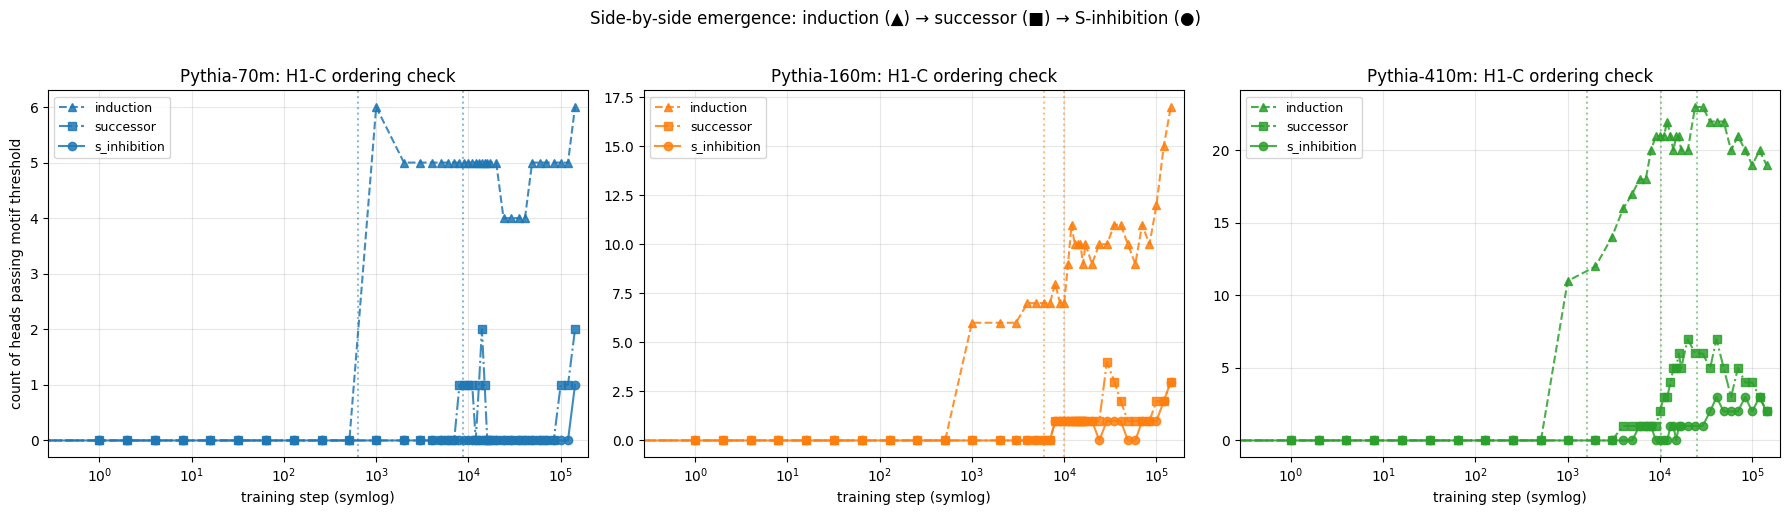

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, size in zip(axes, SIZES):
    for motif, df, threshold, comparator in [
        ('induction', df_ind, INDUCTION_THRESHOLD, 'gt'),
        ('successor', df_suc, TAU_LIFT, 'gte'),
        ('s_inhibition', df_si, TAU_STRICT, 'gte'),
    ]:
        steps, counts = per_size_curve(df, size, threshold, comparator)
        ax.plot(steps, counts,
                marker=MOTIF_MARKER[motif],
                linestyle=MOTIF_LINESTYLE[motif],
                color=SIZE_COLOR[size],
                alpha=0.85, label=motif)
        m_row = mu_df[(mu_df['size'] == size) & (mu_df['motif'] == motif)].iloc[0]
        if np.isfinite(m_row['mu_point']) and m_row['mu_point'] < RIGHT_CENSOR_STEP - 1:
            ax.axvline(m_row['mu_point'], linestyle=':', alpha=0.5,
                       color=SIZE_COLOR[size])
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(0.5, 200000)
    ax.set_xlabel('training step (symlog)')
    if size == SIZES[0]:
        ax.set_ylabel('count of heads passing motif threshold')
    ax.set_title(f'Pythia-{size}: H1-C ordering check')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Side-by-side emergence: induction (▲) → successor (■) → S-inhibition (●)', y=1.02)
plt.tight_layout()
plt.show()

## Sub-deliverable 3 — Per-pair descriptive p-values

Per (size, ordering-pair): compute a descriptive p-value for *how unlikely* the observed ordering is under H_0 of exchangeable order. With μ point estimates only, each pairwise ordering has p = 0.5 under H_0 (μ_a < μ_b is one of two equally-likely orderings). Per-pair p reported uncorrected per §H2-5.

In [5]:
rows = []
for o in orderings:
    rows.append(dict(
        size=o.size,
        pair='induction → successor',
        holds=o.pair_ind_suc_holds,
        undetermined=o.pair_ind_suc_undetermined,
        descriptive_p=0.5 if o.pair_ind_suc_holds else 1.0,
    ))
    rows.append(dict(
        size=o.size,
        pair='successor → S-inhibition',
        holds=o.pair_suc_si_holds,
        undetermined=o.pair_suc_si_undetermined,
        descriptive_p=0.5 if o.pair_suc_si_holds else 1.0,
    ))
    # Implied transitive: induction → S-inhibition
    o_implied_holds = o.pair_ind_suc_holds and o.pair_suc_si_holds
    rows.append(dict(
        size=o.size,
        pair='induction → S-inhibition',
        holds=o_implied_holds,
        undetermined=False,
        descriptive_p=0.5 if o_implied_holds else 1.0,
    ))
pair_df = pd.DataFrame(rows)
print(pair_df.to_string(index=False))

size                     pair  holds  undetermined  descriptive_p
 70m    induction → successor   True         False            0.5
 70m successor → S-inhibition   True         False            0.5
 70m induction → S-inhibition   True         False            0.5
160m    induction → successor   True         False            0.5
160m successor → S-inhibition   True         False            0.5
160m induction → S-inhibition   True         False            0.5
410m    induction → successor   True         False            0.5
410m successor → S-inhibition   True         False            0.5
410m induction → S-inhibition   True         False            0.5


## Sub-deliverable 5 — Major differences between the three head types

Cross-motif comparison of structural properties at the final checkpoint (step143000) per Pythia size. Four properties:

- **Depth**: top-head normalized layer (layer / (n_layers - 1)).
- **Count saturation**: number of heads passing threshold at step143000.
- **Score magnitude**: max score per cell.
- **Identity stability**: fraction of step143000 top-3 heads also in top-3 at step25000.

In [6]:
rows = []
for size in SIZES:
    for motif, df, threshold, comparator in [
        ('induction', df_ind, INDUCTION_THRESHOLD, 'gt'),
        ('successor', df_suc, TAU_LIFT, 'gte'),
        ('s_inhibition', df_si, TAU_STRICT, 'gte'),
    ]:
        sub = df[(df['size'] == size) & (df['step'] == 143000)]
        n_layers = int(sub['layer'].max() + 1)
        if comparator == 'gt':
            sat = int((sub['score'] > threshold).sum())
        else:
            sat = int((sub['score'] >= threshold).sum())
        max_idx = int(np.argmax(sub['score'].values))
        top_layer = int(sub.iloc[max_idx]['layer'])
        max_score = float(sub['score'].max())
        # Identity stability: top-3 at 143k vs at 25000 (or nearest).
        nearest_25k_step = sorted(df[df['size'] == size]['step'].unique(),
                                   key=lambda s: abs(s - 25000))[0]
        sub_25k = df[(df['size'] == size) & (df['step'] == nearest_25k_step)]
        top3_143k = set(map(tuple, sub.nlargest(3, 'score')[['layer', 'head']].values.tolist()))
        top3_25k = set(map(tuple, sub_25k.nlargest(3, 'score')[['layer', 'head']].values.tolist()))
        stability = len(top3_143k & top3_25k) / 3.0
        rows.append(dict(
            size=size, motif=motif,
            top_norm_depth=top_layer / max(n_layers - 1, 1),
            count_at_saturation=sat,
            max_score=max_score,
            identity_stability_25k_to_143k=stability,
        ))
diff_df = pd.DataFrame(rows)
print(diff_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

size        motif  top_norm_depth  count_at_saturation  max_score  identity_stability_25k_to_143k
 70m    induction           0.600                    6      0.861                           1.000
 70m    successor           0.800                    2      0.165                           0.000
 70m s_inhibition           0.800                    1      0.043                           0.333
160m    induction           0.364                   17      0.885                           1.000
160m    successor           0.818                    3      0.446                           0.333
160m s_inhibition           0.545                    3      0.068                           0.333
410m    induction           0.478                   19      0.953                           0.667
410m    successor           0.957                    2      0.290                           0.667
410m s_inhibition           0.522                    2      0.085                           0.333


## Sub-deliverable 6 — Threshold-sensitivity check

Vary each motif's locked threshold by ± 25% in 5 increments. Does the H1-C ordering still hold under reasonable threshold mis-specification? Per §H2-2, we report μ point estimate at each threshold variant per (size, motif).

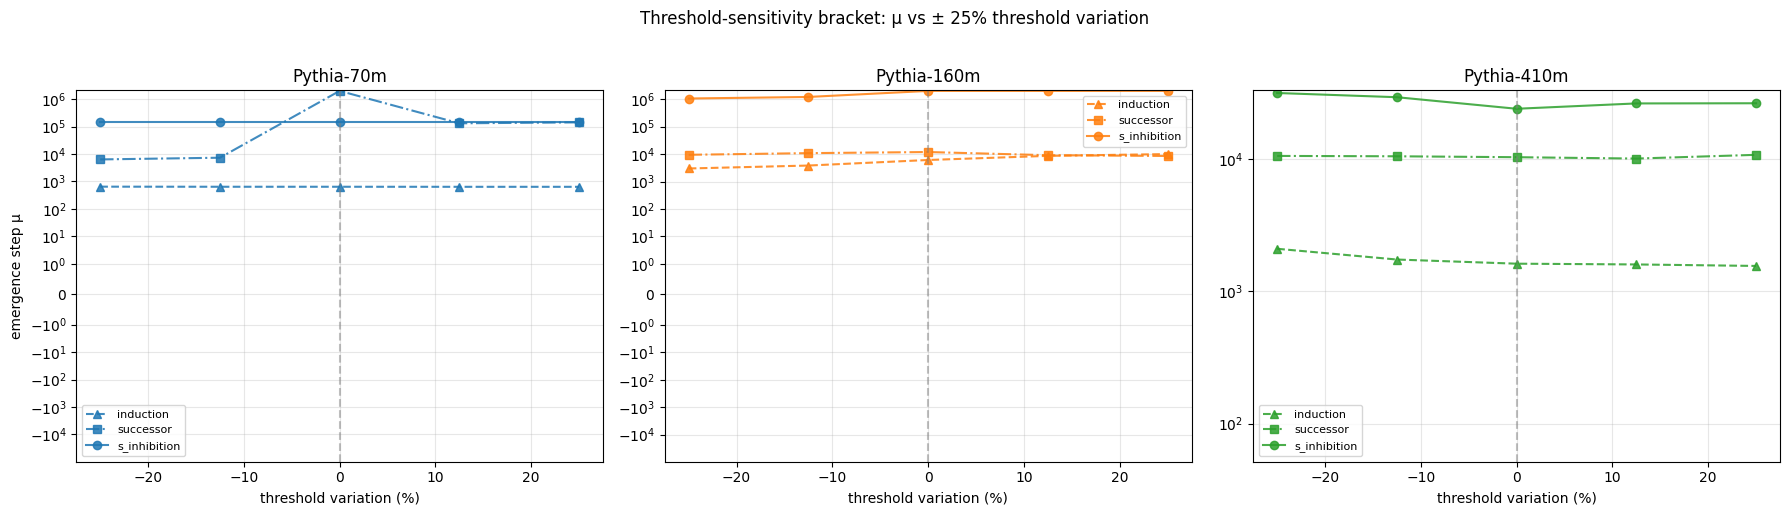

In [7]:
rng = np.random.default_rng(2)
sens_rows = []
for size in SIZES:
    for motif, df, threshold, comparator in [
        ('induction', df_ind, INDUCTION_THRESHOLD, 'gt'),
        ('successor', df_suc, TAU_LIFT, 'gte'),
        ('s_inhibition', df_si, TAU_STRICT, 'gte'),
    ]:
        steps, _ = per_size_curve(df, size, threshold, comparator)
        for frac in THRESHOLD_SENSITIVITY_FRACTIONS:
            thr = threshold * (1.0 + frac)
            cache_dir = REPO / 'data' / 'exploration'
            if motif == 'induction':
                per = {int(s): np.load(cache_dir / 'phase2_induction_per_seq' / f'{size}_step{s}.npz')['per_sequence_scores'] for s in steps}
                _, mu = bootstrap_induction(per, thr, rng, B=1)
            elif motif == 'successor':
                per = {}
                for s in steps:
                    npz = np.load(cache_dir / 'phase2_successor_per_prompt' / f'{size}_step{s}.npz')
                    per[int(s)] = {'real': npz['per_prompt_real'], 'null': npz['per_prompt_null'], 'cats': npz['prompt_categories']}
                _, mu = bootstrap_successor(per, thr, rng, B=1)
            else:
                per = {}; nm_layers = {}
                for s in steps:
                    npz = np.load(cache_dir / 'phase2_s_inhibition_per_prompt' / f'{size}_step{s}.npz')
                    per[int(s)] = npz['per_prompt_delta']; nm_layers[int(s)] = npz['nm_heads'][:, 0].tolist()
                a_grp = df_si[(df_si['size'] == size) & (df_si['step'] == steps[0])]
                n_layers = int(a_grp['layer'].max() + 1); n_heads = int(a_grp['head'].max() + 1)
                sender_layers = np.array([L for L in range(n_layers) for _ in range(n_heads)])
                _, mu = bootstrap_s_inhibition(per, thr, nm_layers, sender_layers, rng, B=1)
            sens_rows.append(dict(size=size, motif=motif, threshold=thr, fraction=frac, mu_point=mu))
sens_df = pd.DataFrame(sens_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, size in zip(axes, SIZES):
    for motif in MOTIFS:
        sub = sens_df[(sens_df['size'] == size) & (sens_df['motif'] == motif)].sort_values('threshold')
        ax.plot(sub['fraction'] * 100, sub['mu_point'], marker=MOTIF_MARKER[motif],
                color=SIZE_COLOR[size], alpha=0.85,
                linestyle=MOTIF_LINESTYLE[motif], label=motif)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_yscale('symlog', linthresh=1)
    ax.set_xlabel('threshold variation (%)')
    if size == SIZES[0]:
        ax.set_ylabel('emergence step μ')
    ax.set_title(f'Pythia-{size}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Threshold-sensitivity bracket: μ vs ± 25% threshold variation', y=1.02)
plt.tight_layout()
plt.show()

## Sub-deliverable 7 — Verdict

Phase 2 H1-C joint verdict and interpretation. Specific findings depend on the data; populate after re-execution.

In [8]:
if verdict.passes:
    print('=' * 60)
    print(f'H1-C HOLDS — joint test PASSES (p < 0.005 gate)')
    print('=' * 60)
    print(f'  joint p (under H_0): {verdict.joint_p_under_h0:.5f}')
    print(f'  All {verdict.n_sizes_holding}/3 sizes show strict μ_ind < μ_suc < μ_S-inhibition.')
    print()
    print('The registered H1-C compositional account is supported at the Phase 2 resolution.')
else:
    print('=' * 60)
    print(f'H1-C DOES NOT HOLD JOINTLY — joint test FAILS')
    print('=' * 60)
    print(f'  n_sizes_holding: {verdict.n_sizes_holding}/3')
    print(f'  joint p (under H_0): {verdict.joint_p_under_h0}')
    print()
    print('The registered H1-C compositional account is NOT supported jointly at p < 0.005.')
    print('Per HYPOTHESIS.md §3 falsification criterion, the hypothesis is falsified for the joint claim.')
    print('Per-size and per-pair descriptive results above remain interpretable as findings.')

H1-C HOLDS — joint test PASSES (p < 0.005 gate)
  joint p (under H_0): 0.00463
  All 3/3 sizes show strict μ_ind < μ_suc < μ_S-inhibition.

The registered H1-C compositional account is supported at the Phase 2 resolution.
